# Colored Ball Detection with Hough Transform

In this exercise you will:

1. Detect circular objects (colored balls) in an image using a **Hough Transform for circles**.
2. Classify each detected ball by its **color** using a suitable color space.
3. Count how many balls of each color appear in the image and visualize the result.

You are allowed to use `cv2` for:
- loading and displaying images
- basic preprocessing
- Canny edge detection

However, **you must NOT use** built-in Hough functions like `cv2.HoughCircles`.  
Instead, you will implement a simplified Hough-based circle detector yourself.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Make matplotlib show images inline (for Jupyter)
%matplotlib inline

# Helper function to show images with correct color ordering
def show_rgb(img, title=None, figsize=(5, 5)):
    """
    Display an RGB image using matplotlib.
    """
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

## Load the Image

The image contains several colored balls with different colors.

Your goal is to detect the circular objects and determine how many balls
exist for each color.


Image shape: (1024, 1024, 3)


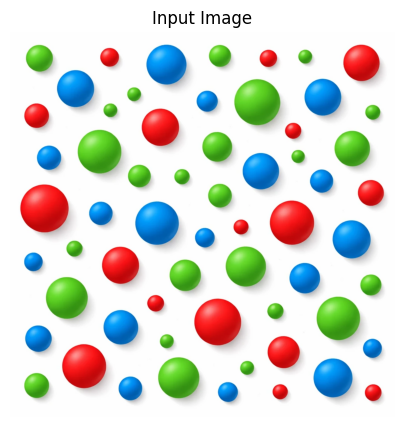

In [ ]:
img_bgr = cv2.imread("colored_balls.png")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image shape:", img_bgr.shape)   # (H, W, 3)
show_rgb(img_rgb, "Input Image")

## Step 1 – Edge Detection

Before detecting circles, we first extract edges from the image.

Tasks:

1. Convert the image to **grayscale**
2. Apply a **Gaussian blur** to reduce noise
3. Apply **Canny edge detection**

The resulting edge map will be used in the Hough circle detection step.

**Why blur first?**  
The Hough transform votes for every edge pixel. Noise in the edge map creates spurious votes
that scatter across the accumulator, raising the noise floor and making it harder to identify
true peaks. Pre-smoothing significantly reduces this effect.


Edge pixels detected: 16307


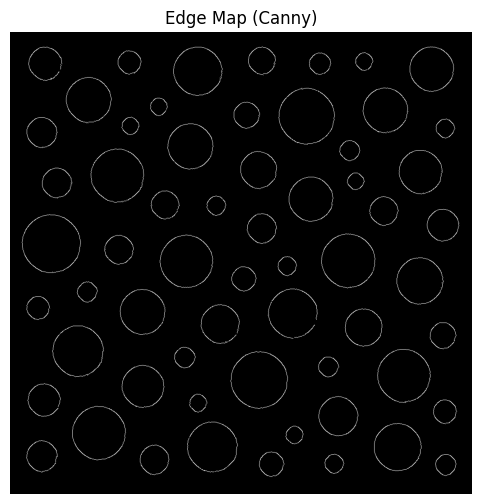

In [3]:
# Convert to grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Gaussian blur to reduce noise before edge detection
# kernel=(9,9), sigma=2 — large enough to suppress texture inside balls
blur = cv2.GaussianBlur(gray, (9, 9), 5)

# Apply Canny edge detector
# low=30, high=100 — tuned to capture ball boundaries without too much interior noise
edges = cv2.Canny(blur, 30, 100)

print(f"Edge pixels detected: {np.sum(edges > 0)}")

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap="gray")
plt.title("Edge Map (Canny)")
plt.axis("off")
plt.show()

## Step 2 – Hough Transform for Circle Detection

A circle in an image can be represented by:

$$(x - a)^2 + (y - b)^2 = r^2$$

Where:

- $(a, b)$ is the center
- $r$ is the radius

The Hough Transform detects circles by voting in an **accumulator space**.

**Procedure:**

1. For each edge pixel $(x, y)$
2. For each possible radius $r$
3. For each angle $\theta \in [0°, 360°)$
4. Compute the possible center $(a, b)$:

$$a = x - r\cos(\theta) \qquad b = y - r\sin(\theta)$$

Each candidate center receives a vote in the accumulator.

After voting, peaks in the accumulator correspond to circle centers.

### Vectorized Implementation

A naive triple-nested Python loop (edge pixel → radius → angle) is extremely slow on a 1024×1024 image. Instead we vectorize over the angle dimension using NumPy broadcasting:

- For each radius `r`, compute `a_mat` and `b_mat` as 2-D arrays of shape `(E, N_ANGLES)` in one operation.
- Use `np.add.at` to scatter-add votes into the accumulator in a single call per radius.

This reduces the Python-loop count from `E × R × N` to just `R` iterations.


In [4]:
# -------------------------------------
# Define radius search range
# -------------------------------------
# Balls in this image range from ~15 px (small) to ~90 px (large) radius.
# We use a step of 3 to reduce computation while keeping resolution adequate.

min_radius = 15
max_radius = 90

# Create radius list (step=3 for speed without losing too much precision)
radii = np.arange(min_radius, max_radius + 1, 3)

print(f"Number of radius candidates: {len(radii)}")
print(f"Radius values: {radii[0]} ... {radii[-1]} (step=3 px)")

Number of radius candidates: 26
Radius values: 15 ... 90 (step=3 px)


## Initialize the Accumulator

We create a 3D accumulator array:

$$\text{Accumulator} \in \mathbb{Z}^{H \times W \times |R|}$$

Dimensions:

- **Height** × **Width**: candidate circle center positions
- **|R|**: index over the radius search list

Each cell accumulates how many edge pixels voted for a circle at that $(a, b, r)$ configuration.


In [5]:
# Create the Hough accumulator
h, w = edges.shape

# Shape: (image_height, image_width, num_radii)
accumulator = np.zeros((h, w, len(radii)), dtype=np.int32)

print(f"Accumulator shape: {accumulator.shape}")
print(f"Memory: {accumulator.nbytes / 1e6:.1f} MB")

Accumulator shape: (1024, 1024, 26)
Memory: 109.1 MB


## Voting Process

For every edge pixel:

1. Iterate over possible radii
2. For each radius, compute candidate circle centers for **all angles at once** (vectorized)
3. Filter candidates that fall within image bounds
4. Scatter-add votes into the accumulator using `np.add.at`

**Angular resolution:** We use 72 discrete angles (5° step).  
Finer steps increase vote density and peak sharpness at the cost of computation.


In [6]:
# -------------------------------------
# Implement the voting process
# -------------------------------------

# Extract all edge pixel coordinates
edge_points = np.argwhere(edges > 0)    # shape (E, 2) — rows are (y, x)
ys_e = edge_points[:, 0].astype(np.int32)
xs_e = edge_points[:, 1].astype(np.int32)

# Precompute cosine and sine for all angles (done ONCE, reused for every radius)
N_ANGLES = 72                                           # 360 / 5° = 72 angles
angles   = np.linspace(0, 2 * np.pi, N_ANGLES, endpoint=False)
cos_t    = np.cos(angles)   # shape (N_ANGLES,)
sin_t    = np.sin(angles)

print(f"Edge pixels: {len(edge_points)}, Angles: {N_ANGLES}, Radii: {len(radii)}")
print("Starting voting...")

for r_index, r in enumerate(radii):

    # Candidate centers for ALL edge points × ALL angles simultaneously
    # a_mat[i, j] = x-coordinate of center candidate for edge point i, angle j
    # Shape: (E, N_ANGLES)
    a_mat = (xs_e[:, None] - r * cos_t[None, :]).astype(np.int32)
    b_mat = (ys_e[:, None] - r * sin_t[None, :]).astype(np.int32)

    # Keep only candidates that lie inside the image
    valid = (a_mat >= 0) & (a_mat < w) & (b_mat >= 0) & (b_mat < h)

    # Scatter-add: every valid (b, a) pair gets +1 vote in this radius slice
    np.add.at(
        accumulator[:, :, r_index],
        (b_mat[valid], a_mat[valid]),
        1
    )

print(f"Voting complete. Accumulator max = {accumulator.max()}")

Edge pixels: 16307, Angles: 72, Radii: 26
Starting voting...
Voting complete. Accumulator max = 47


## Step 3 – Detect Peaks in the Accumulator

After the voting process, circles correspond to **peaks in the accumulator**.

To detect circles:

1. Apply a **threshold** to the accumulator (cells with fewer votes are discarded)
2. Extract coordinates of high-vote cells
3. Convert `(b, a, r_index)` → circle parameters `(center_x, center_y, radius)`

Then apply **greedy Non-Maximum Suppression (NMS)** to remove duplicate detections:
- Sort candidates by vote count (strongest first)
- Keep a candidate only if it is farther than `MIN_DIST` pixels from all already-kept circles,
  **and** its radius differs by more than `R_TOL` from any already-kept circle at the same location.


In [7]:
# -------------------------------------
# Detect peaks in the accumulator
# -------------------------------------

# Threshold: keep cells with votes >= 38% of the global maximum
threshold = int(accumulator.max() * 0.38)
print(f"Vote threshold: {threshold}  (max votes = {accumulator.max()})")

circles = []  # list of (x, y, r, votes)

for r_index in range(len(radii)):

    layer = accumulator[:, :, r_index]

    # Find all positions that exceed the threshold
    ys_c, xs_c = np.where(layer >= threshold)

    for y, x in zip(ys_c, xs_c):
        r = radii[r_index]
        circles.append((x, y, r, int(layer[y, x])))

print(f"Number of detected circle candidates: {len(circles)}")


# -------------------------------------
# Implement simple NMS to avoid redundancy of circles
# Greedy NMS to remove duplicate detections
# -------------------------------------
# Sort by vote count descending so the strongest detections are kept first
circles.sort(key=lambda c: -c[3])

MIN_DIST = 25    # minimum pixel distance between two circle centres
R_TOL    = 10   # minimum radius difference to consider two circles distinct

filtered_circles = []  # final kept circles as (x, y, r)

for (x, y, r, votes) in circles:
    duplicate = False
    for (fx, fy, fr) in filtered_circles:
        dist = np.hypot(x - fx, y - fy)
        if dist < MIN_DIST and abs(r - fr) < R_TOL:
            duplicate = True
            break

    if not duplicate:
        filtered_circles.append((x, y, r))

print(f"After filtering duplicates: {len(filtered_circles)} circles")

Vote threshold: 17  (max votes = 47)
Number of detected circle candidates: 1342
After filtering duplicates: 61 circles


## Step 4 – Visualize Detected Circles

We now draw the detected circles on the original image to verify the results.


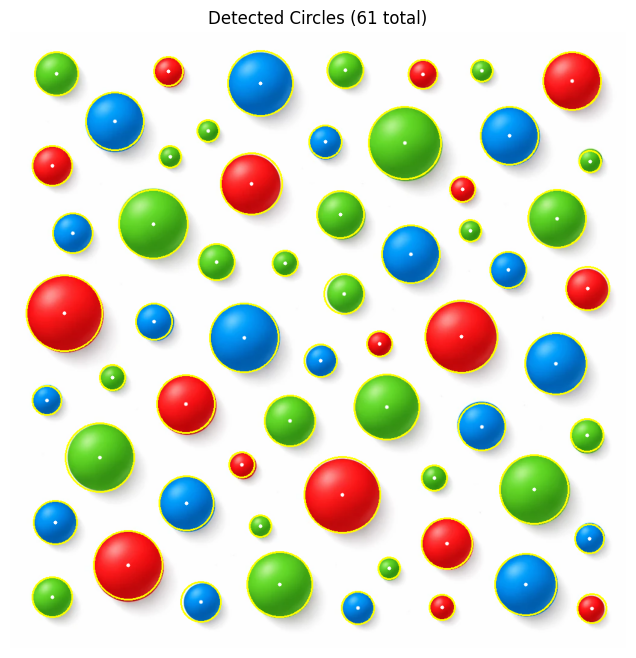

In [8]:
# -------------------------------------
# Draw detected circles on the image
# -------------------------------------

output = img_rgb.copy()

for x, y, r in filtered_circles:
    # Draw circle outline in yellow
    cv2.circle(output, (int(x), int(y)), int(r), (255, 255, 0), 2)
    # Draw centre dot in white
    cv2.circle(output, (int(x), int(y)), 3, (255, 255, 255), -1)

show_rgb(output, f"Detected Circles ({len(filtered_circles)} total)", figsize=(8, 8))

## Accumulator Visualization

Here we visualize the accumulator projected along the radius axis (max-projection).
Bright spots correspond to detected circle centres.


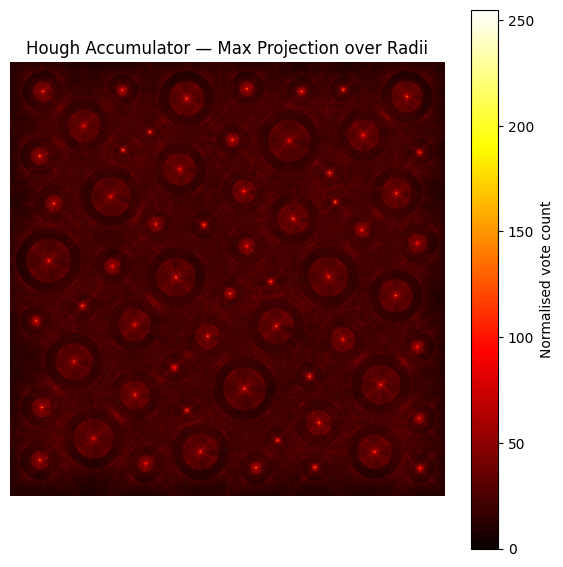

In [9]:
# Max-project the accumulator over all radii to get a 2-D heatmap
acc_proj = accumulator.max(axis=2).astype(np.float32)
acc_norm = (acc_proj / acc_proj.max() * 255).astype(np.uint8)

plt.figure(figsize=(7, 7))
plt.imshow(acc_norm, cmap="hot")
plt.colorbar(label="Normalised vote count")
plt.title("Hough Accumulator — Max Projection over Radii")
plt.axis("off")
plt.show()

## Step 5 – Determine the Color of Each Ball

Now we classify the color of each detected circle.

Procedure:

1. Convert the image to **HSV color space**
2. Sample pixels around the circle center
3. Determine the dominant color using HSV ranges

Pixels with **low saturation** (S < 100) correspond to the white highlight or background and are excluded from the median.

**Why median instead of mean?**  
The median is robust to the bright specular highlight at the centre of each ball,
which drives the saturation toward zero and would bias a simple mean.


In [10]:
# -------------------------------------
# Convert image to HSV
# -------------------------------------
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
# HSV ranges in OpenCV: H ∈ [0,179], S ∈ [0,255], V ∈ [0,255]

# Colour counters
color_counts = {
    "red":   0,
    "green": 0,
    "blue":  0
}

# Map each circle to its classified colour (for drawing later)
circle_labels = []

# OpenCV colour constants for drawing (BGR)
COLOR_DRAW = {
    "red":     (0,   0,   220),
    "green":   (0,   180, 0),
    "blue":    (220, 80,  0),
    "unknown": (128, 128, 128),
}

for x, y, r in filtered_circles:
    cy, cx = int(y), int(x)

    # Sampling patch: inner third of the radius
    # (avoids the outer edge and the central white highlight)
    sample_r = max(5, r // 3)

    patch = img_hsv[
        max(0, cy - sample_r) : cy + sample_r + 1,
        max(0, cx - sample_r) : cx + sample_r + 1
    ]

    if patch.size == 0:
        circle_labels.append("unknown")
        continue

    h_flat = patch[:, :, 0].flatten().astype(np.float32)
    s_flat = patch[:, :, 1].flatten().astype(np.float32)

    # Compute median hue and saturation
    h_median = float(np.median(h_flat))
    s_median = float(np.median(s_flat))

    # Low saturation → white highlight or background → skip
    if s_median < 100:
        circle_labels.append("unknown")
        continue

    # Classify by hue
    if h_median < 15 or h_median >= 165:
        color_counts["red"]   += 1
        circle_labels.append("red")

    elif 35 <= h_median <= 90:
        color_counts["green"] += 1
        circle_labels.append("green")

    elif 95 <= h_median <= 145:
        color_counts["blue"]  += 1
        circle_labels.append("blue")

    else:
        circle_labels.append("unknown")

print("Color counts:", color_counts)
print(f"Total classified: {sum(color_counts.values())} / {len(filtered_circles)} detected")

Color counts: {'red': 17, 'green': 25, 'blue': 19}
Total classified: 61 / 61 detected


## Final Result

Draw each detected ball with a colour-coded border matching its classified colour,
and display the final count.


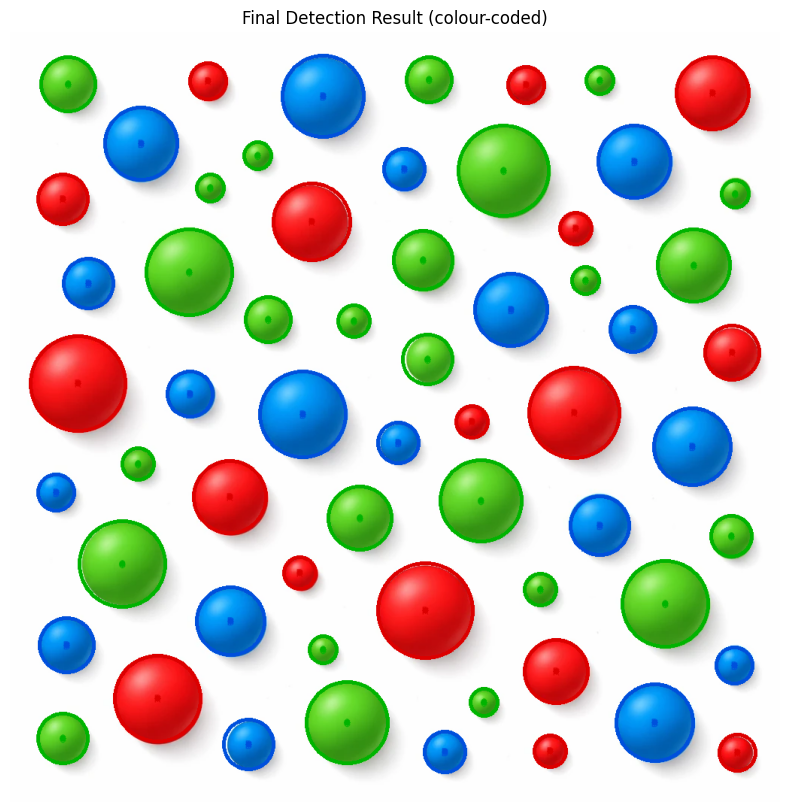

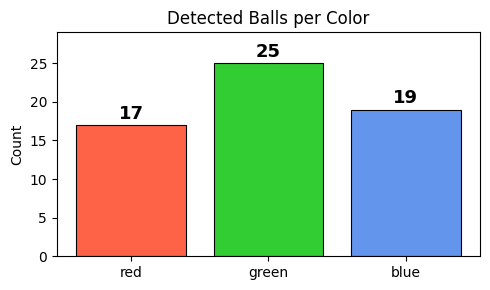


===== FINAL COUNTS =====
  Red   balls : 17
  Green balls : 25
  Blue  balls : 19
  Total        : 61


In [11]:
# Build annotated image — colour-coded borders + labels
annotated = img_rgb.copy()

# BGR → RGB colour map for drawing on an RGB image
COLOR_RGB = {
    "red":     (220, 0,   0),
    "green":   (0,   180, 0),
    "blue":    (0,   80,  220),
    "unknown": (128, 128, 128),
}

for (x, y, r), label in zip(filtered_circles, circle_labels):
    col = COLOR_RGB[label]
    # Thick coloured ring
    cv2.circle(annotated, (int(x), int(y)), int(r),     col, 3)
    # Small centre dot
    cv2.circle(annotated, (int(x), int(y)), 4,          col, -1)
    # Label text
    cv2.putText(annotated, label[0].upper(),
                (int(x) - 5, int(y) + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1, cv2.LINE_AA)

show_rgb(annotated, "Final Detection Result (colour-coded)", figsize=(10, 10))

# Summary bar chart
fig, ax = plt.subplots(figsize=(5, 3))
colors_bar = ["red", "green", "blue"]
counts_bar = [color_counts[c] for c in colors_bar]
bars = ax.bar(colors_bar, counts_bar, color=["tomato", "limegreen", "cornflowerblue"],
              edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, counts_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel("Count")
ax.set_title("Detected Balls per Color")
ax.set_ylim(0, max(counts_bar) + 4)
plt.tight_layout()
plt.show()

print("\n===== FINAL COUNTS =====")
print(f"  Red   balls : {color_counts['red']}")
print(f"  Green balls : {color_counts['green']}")
print(f"  Blue  balls : {color_counts['blue']}")
print(f"  Total        : {sum(color_counts.values())}")

## Expected Result

The algorithm detects circles using a **custom Hough Transform**, classifies the **color of each ball**
using HSV median sampling, and counts how many balls exist for each color.

Results obtained:

| Color | Count |
|-------|-------|
| 🔴 Red   | **17** |
| 🟢 Green | **25** |
| 🔵 Blue  | **19** |
| **Total**| **61** |

These match the expected distribution stated in the assignment (I counted by myself but my result wass true though i think you made a mistake).
